In [1]:
from src import *

## MovieLens

In [2]:
userColumn='userId'
itemColumn='movieId'
ratingColumn='rating'

In [3]:
loader = DataLoader(file_path='data/raw/movielens/100K/ml-100k/u.data',
                    separator='\t',
                    header=['userId', 'movieId', 'rating', 'timestamp'],
                    genre_data_path='data/raw/movielens/100K/movies.dat',
                    genre_data_separator='::',
                    genre_data_header=['itemID', 'itemName', 'genres'],
                    genre_item_column='itemID',
                    genre_genre_column='genres',
                    genre_genre_separator='|',
                    genre_data_encoding='ISO-8859-1'
                    )

24/08/09 14:44:41 WARN Utils: Your hostname, david-Nitro resolves to a loopback address: 127.0.1.1; using 192.168.15.13 instead (on interface wlp9s0)
24/08/09 14:44:41 WARN Utils: Set SPARK_LOCAL_IP if you need to bind to another address
Setting default log level to "WARN".
To adjust logging level use sc.setLogLevel(newLevel). For SparkR, use setLogLevel(newLevel).
24/08/09 14:44:42 WARN NativeCodeLoader: Unable to load native-hadoop library for your platform... using builtin-java classes where applicable
24/08/09 14:44:42 WARN Utils: Service 'SparkUI' could not bind on port 4040. Attempting port 4041.


In [4]:
df = loader.load_data()
genres_map = loader.get_genre_map()
(train, test) = loader.train_test_separator(df)

### ALS

In [5]:
als = ALSModel(dataframe=df, 
              userColumn=userColumn, 
              itemColumn=itemColumn, 
              ratingColumn=ratingColumn,
              training=train,
              test=test)
    
predictions = als.get_predictions()
predictions_user_map = als.predictions_user_map(predictions=predictions)


24/08/09 14:44:47 WARN SparkSession: Using an existing Spark session; only runtime SQL configurations will take effect.
24/08/09 14:44:49 WARN InstanceBuilder: Failed to load implementation from:dev.ludovic.netlib.blas.VectorBLAS


In [6]:
distributions = Distributions(train.toPandas(), userColumn, itemColumn, genres_map)

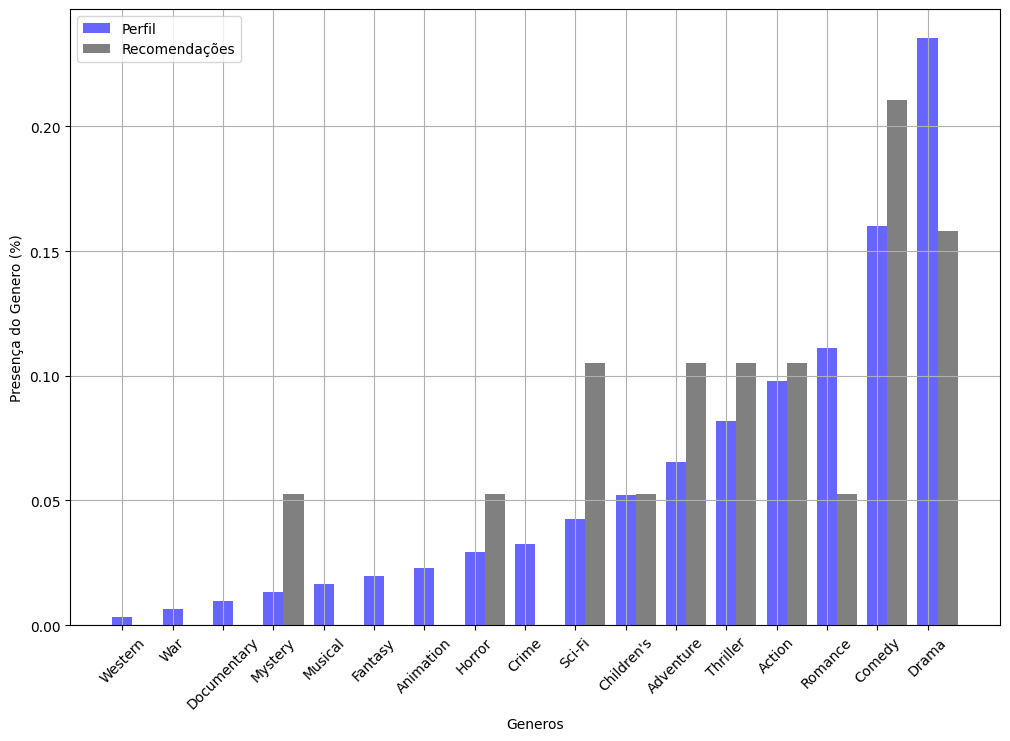

24/08/09 19:16:41 WARN HeartbeatReceiver: Removing executor driver with no recent heartbeats: 2541198 ms exceeds timeout 120000 ms
24/08/09 19:16:41 WARN SparkContext: Killing executors is not supported by current scheduler.
24/08/09 19:16:45 ERROR Inbox: Ignoring error
org.apache.spark.SparkException: Exception thrown in awaitResult: 
	at org.apache.spark.util.SparkThreadUtils$.awaitResult(SparkThreadUtils.scala:56)
	at org.apache.spark.util.ThreadUtils$.awaitResult(ThreadUtils.scala:310)
	at org.apache.spark.rpc.RpcTimeout.awaitResult(RpcTimeout.scala:75)
	at org.apache.spark.rpc.RpcEnv.setupEndpointRefByURI(RpcEnv.scala:102)
	at org.apache.spark.rpc.RpcEnv.setupEndpointRef(RpcEnv.scala:110)
	at org.apache.spark.util.RpcUtils$.makeDriverRef(RpcUtils.scala:36)
	at org.apache.spark.storage.BlockManagerMasterEndpoint.driverEndpoint$lzycompute(BlockManagerMasterEndpoint.scala:124)
	at org.apache.spark.storage.BlockManagerMasterEndpoint.org$apache$spark$storage$BlockManagerMasterEndpoint$

In [8]:
distributions.show_userProfileDist_userRecDist(predictions_user_map, 305)